# Solving Integer Optimization Models

In lecture, we discussed the branch-and-bound algorithm for solving integer optimization problems. In this notebook, we'll run through the algorithm using the optimal investment example from lecture, solving the linear relaxations at each step using Pyomo. In practice, we can use prewritten software to run branch-and-bound on linear integer optimization models, but we'll run through the details in this notebook to demonstrate what is going on under the hood. Recall that our integer optimization problem was as follows:

*Maximize*:  
$ 5000x_1 + 3000x_2 + 2100x_3 + 1500x_4 $

*Subject to*:  

$ 20x_1 + 50x_2 + 50x_3 + 30x_4 \leq 100 $

$ 35x_1 + 22x_2 + 20x_3 + 17x_4 \leq 50 $

$ x_1, x_2, x_3, x_4 \in \{0, 1\} $

As a first step, we solve the *linear relaxation* of this model - in other words, we replace the last set of integer constraints with bounds of zero and 1. We get the following model, with changes marked in $\color{red}{red}$ :


*Maximize*:  
$ 5000x_1 + 3000x_2 + 2100x_3 + 1500x_4 $

*Subject to*:  

$ 20x_1 + 50x_2 + 50x_3 + 30x_4 \leq 100 $

$ 35x_1 + 22x_2 + 20x_3 + 17x_4 \leq 50 $

$ \color{red}{ x_1, x_2, x_3, x_4 \geq 0} $

$   \color{red}{ x_1, x_2, x_3, x_4 \leq 1 }$

Let's solve this using Pyomo. First, if you are using Google Colab, load the necessary packages, as before:

In [ ]:
!pip install pyomo
!apt-get install -y -qq glpk-utils

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.4/13.4 MB 21.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.6/49.6 kB 1.9 MB/s eta 0:00:00
Selecting previously unselected package libsuitesparseconfig5:amd64.
(Reading database ... 123630 files and directories currently installed.)
Preparing to unpack .../libsuitesparseconfig5_1%3a5.10.1+dfsg-4build1_amd64.deb ...
Unpacking libsuitesparseconfig5:amd64 (1:5.10.1+dfsg-4build1) ...
Selecting previously unselected package libamd2:amd64.
Preparing to unpack .../libamd2_1%3a5.10.1+dfsg-4build1_amd64.deb ...
Unpacking libamd2:amd64 (1:5.10.1+dfsg-4build1) ...
Selecting previously unselected package libcolamd2:amd64.
Preparing to unpack .../libcolamd2_1%3a5.10.1+dfsg-4build1_amd64.deb ...
Unpacking libcolamd2:amd64 (1:5.10.1+dfsg-4build1) ...
Selecting previously unselected package libglpk40:amd64.
Preparing to unpack .../libglpk40_5.0-1_amd64.deb ...
Unpacking libglpk40:amd64 (5.0-1) ...
Selecting previously unselected package

Now, let's write out and solve the model:

In [ ]:
from pyomo.environ import *

# Create a model
model = ConcreteModel()

# Define variables (continuous between 0 and 1)
model.x1 = Var(bounds=(0, 1))
model.x2 = Var(bounds=(0, 1))
model.x3 = Var(bounds=(0, 1))
model.x4 = Var(bounds=(0, 1))

# Objective function
model.obj = Objective(
    expr=5000 * model.x1 + 3000 * model.x2 + 2100 * model.x3 + 1500 * model.x4,
    sense=maximize
)

# Constraints
model.con1 = Constraint(expr=20 * model.x1 + 50 * model.x2 + 50 * model.x3 + 30 * model.x4 <= 100)
model.con2 = Constraint(expr=35 * model.x1 + 22 * model.x2 + 20 * model.x3 + 17 * model.x4 <= 50)

# Solve the problem
solver = SolverFactory('glpk')  # Ensure the solver is installed in your environment
result = solver.solve(model)

# Display the results
print("Status:", result.solver.status)
print("Termination Condition:", result.solver.termination_condition)
print("Objective Value:", model.obj())
print("x1:", model.x1())
print("x2:", model.x2())
print("x3:", model.x3())
print("x4:", model.x4())

Objective Value: 7045.454545454546
x1: 1.0
x2: 0.681818181818182
x3: 0.0
x4: 0.0


This gives us the first node of our tree:

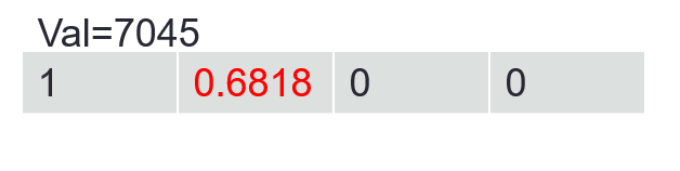

Now, let's branch on $x_2$. We'll follow the left side of the tree from lecture, where $x_2=1$. We'll add this as a constraint to our model:

*Maximize*:  
$ 5000x_1 + 3000x_2 + 2100x_3 + 1500x_4 $

*Subject to*:  

$ 20x_1 + 50x_2 + 50x_3 + 30x_4 \leq 100 $

$ 35x_1 + 22x_2 + 20x_3 + 17x_4 \leq 50 $

$  x_1, x_2, x_3, x_4 \geq 0 $

$   x_1, x_2, x_3, x_4 \leq 1 $

$\color{red}{ x_2 = 1}$

In Pyomo, this is easily done by adding a new contraint, highlighted in the code below:

In [ ]:
# Create a model
model = ConcreteModel()

# Define variables (continuous between 0 and 1)
model.x1 = Var(bounds=(0, 1))
model.x2 = Var(bounds=(0, 1))
model.x3 = Var(bounds=(0, 1))
model.x4 = Var(bounds=(0, 1))

# Objective function
model.obj = Objective(
    expr=5000 * model.x1 + 3000 * model.x2 + 2100 * model.x3 + 1500 * model.x4,
    sense=maximize
)

# Constraints
model.con1 = Constraint(expr=20 * model.x1 + 50 * model.x2 + 50 * model.x3 + 30 * model.x4 <= 100)
model.con2 = Constraint(expr=35 * model.x1 + 22 * model.x2 + 20 * model.x3 + 17 * model.x4 <= 50)
# NEW CONSTRAINT
model.con3 = Constraint(expr=model.x2==1)

# Solve the problem
solver = SolverFactory('glpk')  # Ensure the solver is installed in your environment
result = solver.solve(model)

# Display the results
print("Status:", result.solver.status)
print("Termination Condition:", result.solver.termination_condition)
print("Objective Value:", model.obj())
print("x1:", model.x1())
print("x2:", model.x2())
print("x3:", model.x3())
print("x4:", model.x4())

Objective Value: 7000.0
x1: 0.8
x2: 1.0
x3: 0.0
x4: 0.0


We've now added on a new node to the tree:

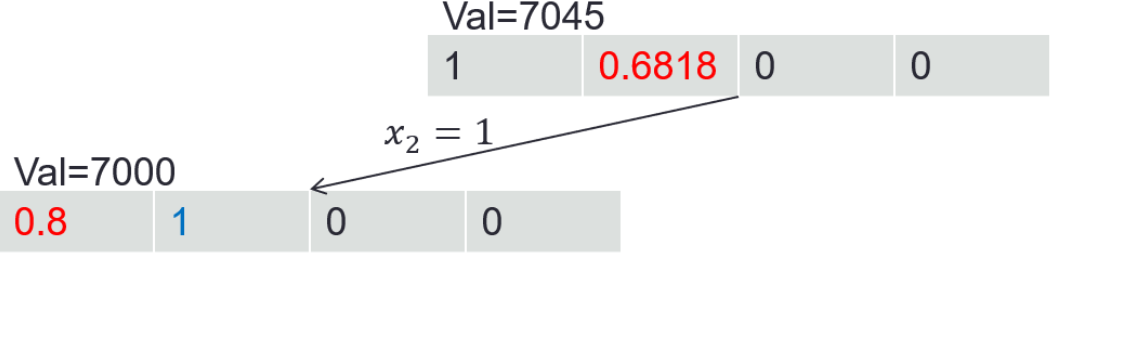

Now we'll branch on $x_1$. For $x_1=0$, our model is now:

*Maximize*:  
$ 5000x_1 + 3000x_2 + 2100x_3 + 1500x_4 $

*Subject to*:  

$ 20x_1 + 50x_2 + 50x_3 + 30x_4 \leq 100 $

$ 35x_1 + 22x_2 + 20x_3 + 17x_4 \leq 50 $

$  x_1, x_2, x_3, x_4 \geq 0 $

$   x_1, x_2, x_3, x_4 \leq 1 $

$x_2 = 1$

$\color{red}{ x_1 = 0}$

In Pyomo:

In [ ]:
# Create a model
model = ConcreteModel()

# Define variables (continuous between 0 and 1)
model.x1 = Var(bounds=(0, 1))
model.x2 = Var(bounds=(0, 1))
model.x3 = Var(bounds=(0, 1))
model.x4 = Var(bounds=(0, 1))

# Objective function
model.obj = Objective(
    expr=5000 * model.x1 + 3000 * model.x2 + 2100 * model.x3 + 1500 * model.x4,
    sense=maximize
)

# Constraints
model.con1 = Constraint(expr=20 * model.x1 + 50 * model.x2 + 50 * model.x3 + 30 * model.x4 <= 100)
model.con2 = Constraint(expr=35 * model.x1 + 22 * model.x2 + 20 * model.x3 + 17 * model.x4 <= 50)
model.con3 = Constraint(expr=model.x2==1)
# NEW CONSTRAINT
model.con4 = Constraint(expr=model.x1==0)

# Solve the problem
solver = SolverFactory('glpk')  # Ensure the solver is installed in your environment
result = solver.solve(model)

# Display the results
print("Status:", result.solver.status)
print("Termination Condition:", result.solver.termination_condition)
print("Objective Value:", model.obj())
print("x1:", model.x1())
print("x2:", model.x2())
print("x3:", model.x3())
print("x4:", model.x4())

Objective Value: 5340.0
x1: 0.0
x2: 1.0
x3: 0.4
x4: 1.0


Thus, a new node:

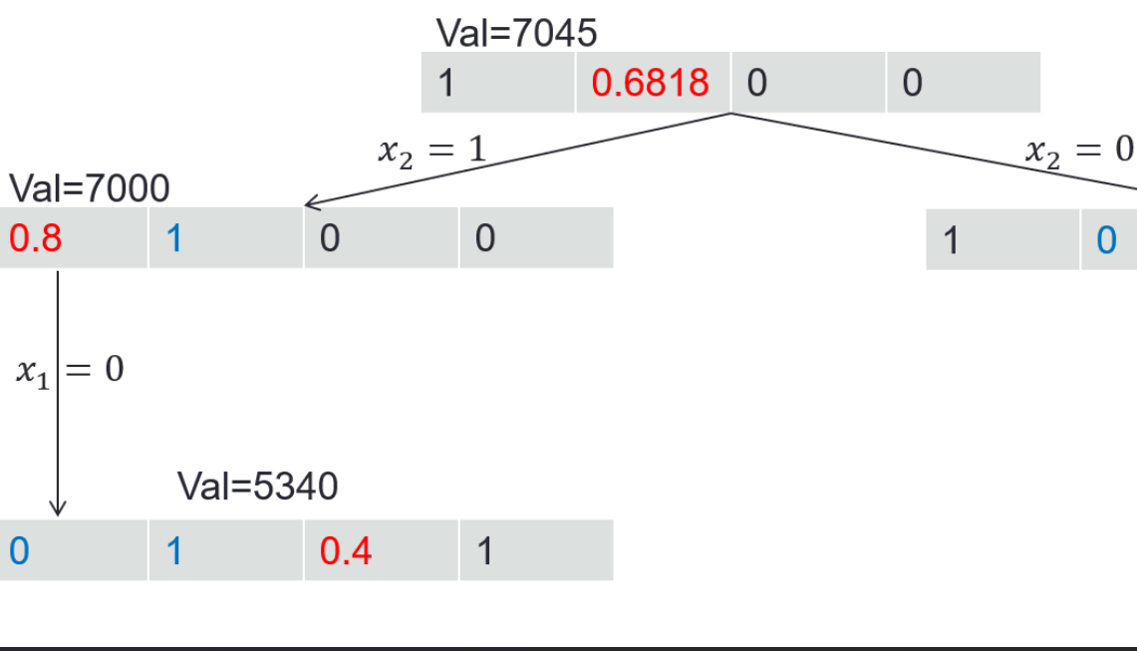

 For $x_1=1$, our model is now:

*Maximize*:  
$ 5000x_1 + 3000x_2 + 2100x_3 + 1500x_4 $

*Subject to*:  

$ 20x_1 + 50x_2 + 50x_3 + 30x_4 \leq 100 $

$ 35x_1 + 22x_2 + 20x_3 + 17x_4 \leq 50 $

$  x_1, x_2, x_3, x_4 \geq 0 $

$   x_1, x_2, x_3, x_4 \leq 1 $

$ x_2 = 1$

$\color{red}{ x_1 = 1}$

Or in Pyomo:

In [ ]:
# Create a model
model = ConcreteModel()

# Define variables (continuous between 0 and 1)
model.x1 = Var(bounds=(0, 1))
model.x2 = Var(bounds=(0, 1))
model.x3 = Var(bounds=(0, 1))
model.x4 = Var(bounds=(0, 1))

# Objective function
model.obj = Objective(
    expr=5000 * model.x1 + 3000 * model.x2 + 2100 * model.x3 + 1500 * model.x4,
    sense=maximize
)

# Constraints
model.con1 = Constraint(expr=20 * model.x1 + 50 * model.x2 + 50 * model.x3 + 30 * model.x4 <= 100)
model.con2 = Constraint(expr=35 * model.x1 + 22 * model.x2 + 20 * model.x3 + 17 * model.x4 <= 50)
model.con3 = Constraint(expr=model.x2==1)
# NEW CONSTRAINT
model.con4 = Constraint(expr=model.x1==1)

# Solve the problem
solver = SolverFactory('glpk')  # Ensure the solver is installed in your environment
result = solver.solve(model)

# Display the results
print("Status:", result.solver.status)
print("Termination Condition:", result.solver.termination_condition)
print("Objective Value:", model.obj())
print("x1:", model.x1())
print("x2:", model.x2())
print("x3:", model.x3())
print("x4:", model.x4())

ERROR:pyomo.common.numeric_types:evaluating object as numeric value: x1
    (object: <class 'pyomo.core.base.var.ScalarVar'>)
No value for uninitialized NumericValue object x1


Status: ok
Termination Condition: infeasible


ValueError: No value for uninitialized NumericValue object x1

As we saw in lecture, this is infeasible, so we prune this entire branch, and do not pursue it any longer!

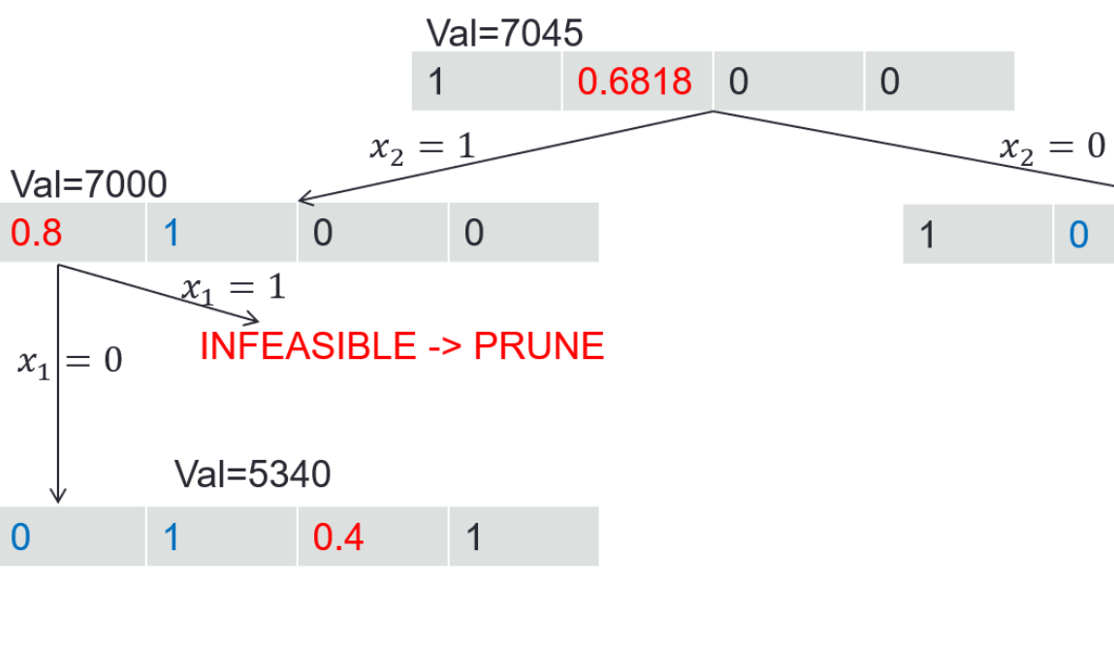

Now we'll branch on $x_3$, going back to the $x_1=0$ branch that we have not pruned yet. For $x_3=0$, the model is

*Maximize*:  
$ 5000x_1 + 3000x_2 + 2100x_3 + 1500x_4 $

*Subject to*:  

$ 20x_1 + 50x_2 + 50x_3 + 30x_4 \leq 100 $

$ 35x_1 + 22x_2 + 20x_3 + 17x_4 \leq 50 $

$  x_1, x_2, x_3, x_4 \geq 0 $

$   x_1, x_2, x_3, x_4 \leq 1 $

$ x_2 = 1$

$ x_1 = 0$

$ x_3 = 0$


In [ ]:

# Create a model
model = ConcreteModel()

# Define variables (continuous between 0 and 1)
model.x1 = Var(bounds=(0, 1))
model.x2 = Var(bounds=(0, 1))
model.x3 = Var(bounds=(0, 1))
model.x4 = Var(bounds=(0, 1))

# Objective function
model.obj = Objective(
    expr=5000 * model.x1 + 3000 * model.x2 + 2100 * model.x3 + 1500 * model.x4,
    sense=maximize
)

# Constraints
model.con1 = Constraint(expr=20 * model.x1 + 50 * model.x2 + 50 * model.x3 + 30 * model.x4 <= 100)
model.con2 = Constraint(expr=35 * model.x1 + 22 * model.x2 + 20 * model.x3 + 17 * model.x4 <= 50)
model.con3 = Constraint(expr=model.x2==1)
model.con4 = Constraint(expr=model.x1==0)
# NEW CONSTRAINT
model.con5 = Constraint(expr=model.x3==0)

# Solve the problem
solver = SolverFactory('glpk')  # Ensure the solver is installed in your environment
result = solver.solve(model)

# Display the results
print("Status:", result.solver.status)
print("Termination Condition:", result.solver.termination_condition)
print("Objective Value:", model.obj())
print("x1:", model.x1())
print("x2:", model.x2())
print("x3:", model.x3())
print("x4:", model.x4())


Status: ok
Termination Condition: optimal
Objective Value: 4500.0
x1: 0.0
x2: 1.0
x3: 0.0
x4: 1.0


We have an all integral solution! And the objective value is the first (and therefore, current best) integer solution, so we mark it in green and prune.

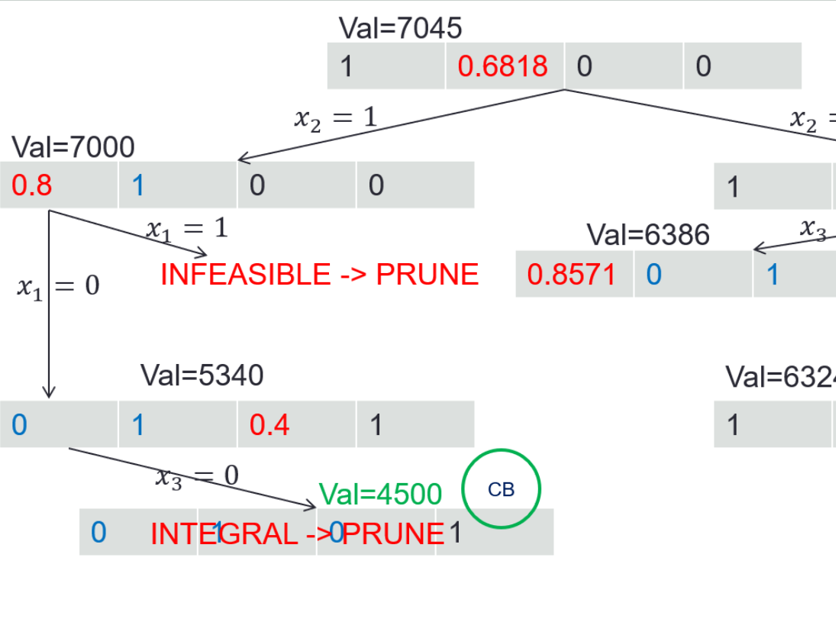

Let's check the other branch, with $x_3=1$:



In [ ]:
# Create a model
model = ConcreteModel()

# Define variables (continuous between 0 and 1)
model.x1 = Var(bounds=(0, 1))
model.x2 = Var(bounds=(0, 1))
model.x3 = Var(bounds=(0, 1))
model.x4 = Var(bounds=(0, 1))

# Objective function
model.obj = Objective(
    expr=5000 * model.x1 + 3000 * model.x2 + 2100 * model.x3 + 1500 * model.x4,
    sense=maximize
)

# Constraints
model.con1 = Constraint(expr=20 * model.x1 + 50 * model.x2 + 50 * model.x3 + 30 * model.x4 <= 100)
model.con2 = Constraint(expr=35 * model.x1 + 22 * model.x2 + 20 * model.x3 + 17 * model.x4 <= 50)
model.con3 = Constraint(expr=model.x2==1)
model.con4 = Constraint(expr=model.x1==0)
# NEW CONSTRAINT
model.con5 = Constraint(expr=model.x3==1)

# Solve the problem
solver = SolverFactory('glpk')  # Ensure the solver is installed in your environment
result = solver.solve(model)

# Display the results
print("Status:", result.solver.status)
print("Termination Condition:", result.solver.termination_condition)
print("Objective Value:", model.obj())
print("x1:", model.x1())
print("x2:", model.x2())
print("x3:", model.x3())
print("x4:", model.x4())

Status: ok
Termination Condition: optimal
Objective Value: 5100.0
x1: 0.0
x2: 1.0
x3: 1.0
x4: 0.0


This branch is integral again, so we prune, and also note that at 5100, it has a higher objective value than our current best solution (4500), so it is now our new current best solution.

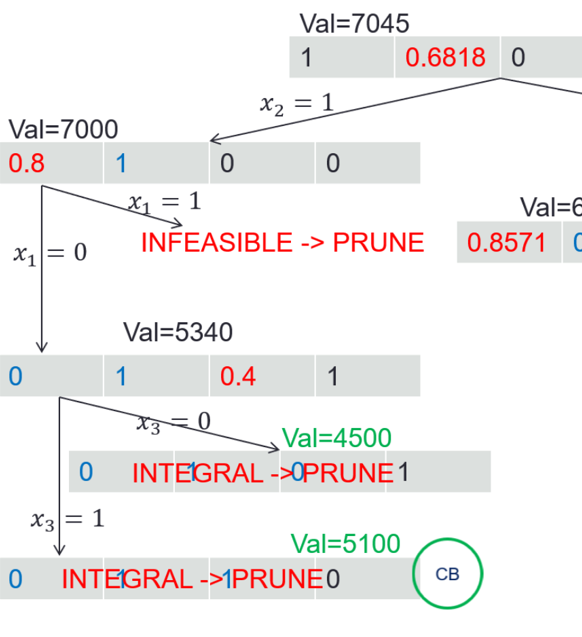

We are not done yet: we would have to explore the $x_2=0$ side of the tree to see using the same approach. In the lesson we saw that all integral solutions on the other side of the tree were infeasible or less than 5100, so we have indeed found an optimal solution. Hopefully, the approach is starting to make sense - though you are encouraged to run through the other side of the tree using this same approach to test your understanding.